# lab-2

In [86]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. import and reading data

In [68]:
df = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 2. exploratory data analysis

In [70]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [71]:
df.describe(include=['str']).T

,count,unique,top,freq
MSZoning,1460,5,RL,1151
Street,1460,2,Pave,1454
Alley,91,2,Grvl,50
LotShape,1460,4,Reg,925
LandContour,1460,4,Lvl,1311
Utilities,1460,2,AllPub,1459
LotConfig,1460,5,Inside,1052
LandSlope,1460,3,Gtl,1382
Neighborhood,1460,25,NAmes,225
Condition1,1460,9,Norm,1260


## 3. data preparation

In [72]:
df['MSSubClass'] = df['MSSubClass'].astype(str)

df.dtypes.value_counts()

str        44
int64      34
float64     3
Name: count, dtype: int64

In [73]:
missing = df.isna().sum()[lambda s: s > 0].sort_values(ascending=False)
missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## 4. input and output variables

In [74]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['Id']).columns.tolist()
categorical_cols = df.select_dtypes(include=[str]).columns.tolist()

In [75]:
TARGET = 'SalePrice'

X = df.drop(columns=[TARGET, 'Id']).copy()
y = df[TARGET].copy()

## 5. split into training and test samples

In [76]:
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape} ({len(X_train)/len(X):.0%})")
print(f"X_val:   {X_val.shape} ({len(X_val)/len(X):.0%})")
print(f"X_test:  {X_test.shape} ({len(X_test)/len(X):.0%})")

X_train: (876, 79) (60%)
X_val:   (292, 79) (20%)
X_test:  (292, 79) (20%)


## 6. processing of missing values

In [77]:
missing_train = X_train.isna().sum()
missing_train[lambda s: s > 0].sort_values(ascending=False)

PoolQC          870
MiscFeature     840
Alley           819
Fence           698
MasVnrType      504
FireplaceQu     401
LotFrontage     163
GarageType       49
GarageYrBlt      49
GarageFinish     49
GarageQual       49
GarageCond       49
BsmtCond         23
BsmtFinType1     23
BsmtExposure     23
BsmtQual         23
BsmtFinType2     23
MasVnrArea        5
Electrical        1
dtype: int64

In [78]:
none_means_absence = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 
       'GarageType', 'GarageCond', 'GarageFinish', 'GarageQual', 'BsmtFinType2', 
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1']


def build_preprocessor(X_fit_raw):
    Xf = X_fit_raw.copy()
    for col in none_means_absence:
       Xf[col] = Xf[col].fillna('None')
    
    cat_cols = Xf.select_dtypes(include=[str]).columns.tolist()
    num_cols = Xf.select_dtypes(include=[np.number]).columns.tolist()

    remaining_cat = [c for c in cat_cols if Xf[c].isna().any()]
    remaining_num = [c for c in num_cols if Xf[c].isna().any()]

    cat_imputer = SimpleImputer(strategy='most_frequent')
    if remaining_cat:
        cat_imputer.fit(Xf[remaining_cat])
        Xf[remaining_cat] = cat_imputer.transform(Xf[remaining_cat])

    num_imputer = SimpleImputer(strategy='median')
    if remaining_num:
        num_imputer.fit(Xf[remaining_num])
        Xf[remaining_num] = num_imputer.transform(Xf[remaining_num])

    iqr_bounds = {}
    for c in num_cols:
        q1, q3 = Xf[c].quantile(0.25), Xf[c].quantile(0.75)
        iqr = q3 - q1
        iqr_bounds[c] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
        Xf[c] = Xf[c].clip(lower=iqr_bounds[c][0], upper=iqr_bounds[c][1])

        ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        ohe.fit(Xf[cat_cols])

        scaler = StandardScaler()
        scaler.fit(Xf[num_cols])


    return dict(cat_cols=cat_cols, num_cols=num_cols, 
                remaining_cat=remaining_cat, remaining_num=remaining_num, 
                cat_imputer=cat_imputer, num_imputer=num_imputer,
                iqr_bounds=iqr_bounds, ohe=ohe, scaler=scaler)


def apply_preptocessor(X_raw, prep):
    Xr = X_raw.copy()
    for col in none_means_absence:
        Xr[col] = Xr[col].fillna('None')

    if prep['remaining_cat']:
        Xr[prep['remaining_cat']] = prep['cat_imputer'].transform(Xr[prep['remaining_cat']])
    if prep['remaining_num']:
        Xr[prep['remaining_num']] = prep['num_imputer'].transform(Xr[prep['remaining_num']])

    for c in prep['num_cols']:
        lo, hi = prep['iqr_bounds'][c]
        Xr[c] = Xr[c].clip(lower=lo, upper=hi)

    X_cat = pd.DataFrame(
        prep['ohe'].transform(Xr[prep['cat_cols']]),
        columns=prep['ohe'].get_feature_names_out(prep['cat_cols']),
        index=Xr.index
    )
    X_num = pd.DataFrame(
        prep['scaler'].transform(Xr[prep['num_cols']]),
        columns=prep['num_cols'],
        index=Xr.index
    )
    
    return pd.concat([X_num, X_cat], axis=1)

In [80]:
prep = build_preprocessor(X_train)

X_train_final = apply_preptocessor(X_train, prep)
X_val_final = apply_preptocessor(X_val, prep)
X_test_final = apply_preptocessor(X_test, prep)

y_train_final = y_train.reset_index(drop=True)
y_val_final = y_val.reset_index(drop=True)
y_test_final = y_test.reset_index(drop=True)
X_train_final = X_train_final.reset_index(drop=True)
X_val_final = X_val_final.reset_index(drop=True)
X_test_final = X_test_final.reset_index(drop=True)

print(f"X_train_final: {X_train_final.shape}")
print(f"X_val_final:   {X_val_final.shape}")
print(f"X_test_final:  {X_test_final.shape}")

X_train_final: (876, 310)
X_val_final:   (292, 310)
X_test_final:  (292, 310)


In [85]:
print('Before scaling:')
display(X_train[prep['num_cols']].agg(['mean', 'std']).T.head())

print('After scaling:')
display(X_train_final[prep['num_cols']].agg(['mean', 'std']).T.head())

Before scaling:


,mean,std
LotFrontage,70.276297,25.662639
LotArea,10880.632420,11939.408382
OverallQual,6.110731,1.380790
OverallCond,5.597032,1.132760
YearBuilt,1970.331050,30.876972


After scaling:


,mean,std
LotFrontage,-1.135571e-16,1.000571
LotArea,2.027805e-17,1.000571
OverallQual,-2.311697e-16,1.000571
OverallCond,1.419463e-16,1.000571
YearBuilt,1.017958e-15,1.000571


## 7. linear regression

In [87]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [91]:
lr = LinearRegression()
lr.fit(X_train_final, y_train_final)

y_train_pred_lr = lr.predict(X_train_final)
y_val_pred_lr = lr.predict(X_val_final)

lr_train_metrics = regression_metrics(y_train_final, y_train_pred_lr)
lr_val_metrics = regression_metrics(y_val_final, y_val_pred_lr)

print('Linear Regression metrics:')
lr_metrics_table = pd.DataFrame({'train': lr_train_metrics, 'validation': lr_val_metrics}).T
lr_metrics_table

Linear Regression metrics:


,MAE,MSE,RMSE,R2
train,12193.623742,3.363774e+08,18340.594103,0.943527
validation,18864.458575,8.177026e+08,28595.499901,0.863453


## 8. ridge regression

In [95]:
ridge_alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000]

ridge_results = []
ridge_models = {}
for a in ridge_alphas:
    model = Ridge(alpha=a, random_state=RANDOM_STATE)
    model.fit(X_train_final, y_train_final)
    ridge_models[a] = model
    y_val_pred = model.predict(X_val_final)
    m = regression_metrics(y_val_final, y_val_pred)
    m['alpha'] = a
    ridge_results.append(m)

ridge_results_df = pd.DataFrame(ridge_results)[['alpha', 'MAE', 'MSE', 'RMSE', 'R2']]
ridge_results_df

,alpha,MAE,MSE,RMSE,R2
0,0.01,18837.305311,8.151154e+08,28550.226522,0.863885
1,0.10,18681.607269,7.989968e+08,28266.531504,0.866576
2,1.00,18284.605897,7.464363e+08,27320.985773,0.875353
3,5.00,17281.905753,6.934832e+08,26334.069058,0.884196
4,10.00,16812.617320,6.775408e+08,26029.614299,0.886858
5,50.00,16278.738515,6.975903e+08,26411.934500,0.883510
6,100.00,16712.592420,7.410757e+08,27222.706179,0.876249
7,500.00,19008.438852,9.521223e+08,30856.479300,0.841006
8,1000.00,20471.061584,1.118516e+09,33444.221556,0.813220
9,5000.00,29584.509975,2.052560e+09,45305.188709,0.657245


In [101]:
best_ridge_alpha = ridge_results_df.loc[ridge_results_df['RMSE'].idxmin(), 'alpha']
ridge_best = ridge_models[best_ridge_alpha]

print('Best ridge alpha:', best_ridge_alpha)

Best ridge alpha: 10.0


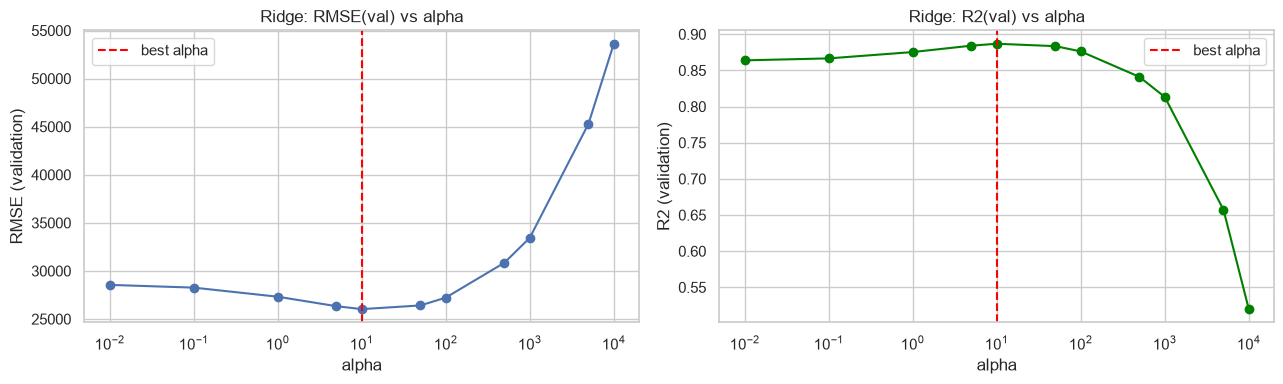

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ridge_results_df['alpha'], ridge_results_df['RMSE'], marker='o')
axes[0].set_xscale('log')
axes[0].axvline(best_ridge_alpha, color='red', linestyle='--', label='best alpha')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('RMSE (validation)')
axes[0].set_title('Ridge: RMSE(val) vs alpha')
axes[0].legend()

axes[1].plot(ridge_results_df['alpha'], ridge_results_df['R2'], marker='o', color='green')
axes[1].set_xscale('log')
axes[1].axvline(best_ridge_alpha, color='red', linestyle='--', label='best alpha')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('R2 (validation)')
axes[1].set_title('Ridge: R2(val) vs alpha')
axes[1].legend()
plt.tight_layout()

## 9. lasso regression

In [119]:
lasso_alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000, 5000, 10000]

lasso_results = []
lasso_models = {}
for a in lasso_alphas:
    model = Lasso(alpha=a, random_state=RANDOM_STATE, max_iter=50000)
    model.fit(X_train_final, y_train_final)
    lasso_models[a] = model
    y_val_pred = model.predict(X_val_final)
    m = regression_metrics(y_val_final, y_val_pred)
    m['alpha'] = a
    m['n_nonzero_coef'] = int(np.sum(model.coef_ != 0))
    lasso_results.append(m)

lasso_results_df = pd.DataFrame(lasso_results)[['alpha', 'MAE', 'MSE', 'RMSE', 'R2', 'n_nonzero_coef']]
lasso_results_df

/home/psa/anaconda3/envs/Machine-Learning-Technologies/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.296693e+10, tolerance: 5.218e+08
  model = cd_fast.enet_coordinate_descent(
/home/psa/anaconda3/envs/Machine-Learning-Technologies/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.277779e+10, tolerance: 5.218e+08
  model = cd_fast.enet_coordinate_descent(


,alpha,MAE,MSE,RMSE,R2,n_nonzero_coef
0,0.01,18685.276571,7.997548e+08,28279.935501,0.866450,278
1,0.10,18654.836297,7.977541e+08,28244.541697,0.866784,274
2,1.00,18535.177192,7.868018e+08,28049.987855,0.868613,267
3,5.00,18127.632931,7.488684e+08,27365.460158,0.874947,225
4,10.00,17781.344547,7.193917e+08,26821.478085,0.879870,220
5,50.00,16489.718705,6.397675e+08,25293.626551,0.893166,154
6,100.00,16230.803965,6.332388e+08,25164.236359,0.894256,107
7,500.00,16731.370557,7.466374e+08,27324.666836,0.875320,50
8,1000.00,18207.587588,8.739588e+08,29562.793618,0.854059,29
9,5000.00,21202.898039,1.122339e+09,33501.325509,0.812582,13


In [ ]:
best_lasso_alpha = lasso_results_df.loc[lasso_results_df['RMSE'].idxmin(), 'alpha']
lasso_best = lasso_models[best_lasso_alpha]

print('Best lasso alpha:', best_lasso_alpha)
print(f"Number of coefficients zeroed out by Lasso at alpha={best_lasso_alpha}:")

Best ridge alpha: 100.0


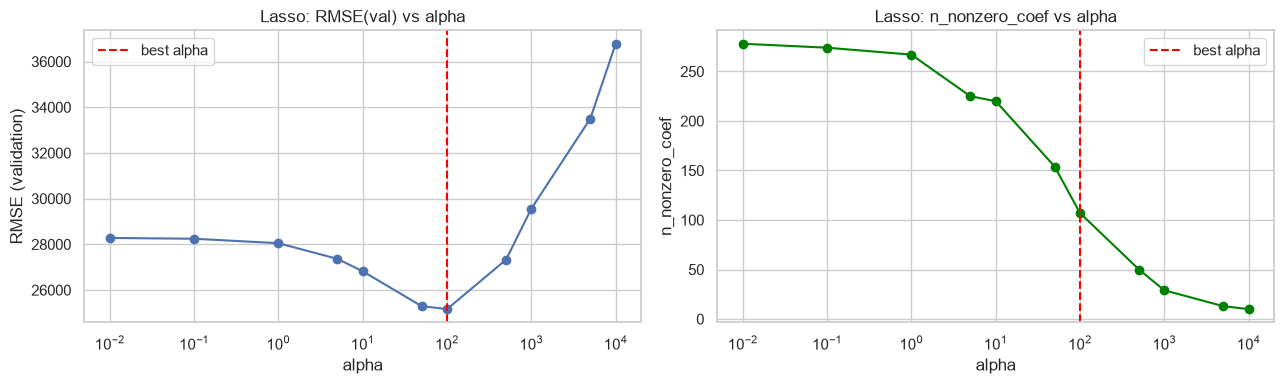

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(lasso_results_df['alpha'], lasso_results_df['RMSE'], marker='o')
axes[0].set_xscale('log')
axes[0].axvline(best_lasso_alpha, color='red', linestyle='--', label='best alpha')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('RMSE (validation)')
axes[0].set_title('Lasso: RMSE(val) vs alpha')
axes[0].legend()

axes[1].plot(lasso_results_df['alpha'], lasso_results_df['n_nonzero_coef'], marker='o', color='green')
axes[1].set_xscale('log')
axes[1].axvline(best_lasso_alpha, color='red', linestyle='--', label='best alpha')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('n_nonzero_coef')
axes[1].set_title('Lasso: n_nonzero_coef vs alpha')
axes[1].legend()
plt.tight_layout()

## 10. linear regression